In [217]:
## import dependencies
import os
import re
import sys
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt

## Add the path to the DiscEvolution directory
sys.path.append('/Users/ben/Downloads/Planet Formation/Code/DiscEvolution Core Accretion')

## import DiscEvolution modules
from DiscEvolution.constants import *
from DiscEvolution.grid import Grid
from DiscEvolution.star import SimpleStar
from DiscEvolution.eos import IrradiatedEOS, LocallyIsothermalEOS, SimpleDiscEOS
from DiscEvolution.disc import *
from DiscEvolution.viscous_evolution import ViscousEvolution, ViscousEvolutionFV, LBP_Solution, HybridWindModel, TaboneSolution
from DiscEvolution.disc import AccretionDisc
from DiscEvolution.dust import *
from DiscEvolution.dust import PlanetesimalFormation
from DiscEvolution.planet_formation import *
from DiscEvolution.diffusion import TracerDiffusion
from DiscEvolution.opacity import Tazzari2016
from DiscEvolution.chemistry import *

In [218]:
## Method to read data from an HDF5 dataset or group

def read_hdf5_array(obj):
    """
    Read data from either an HDF5 dataset or an HDF5 group.
    """

    ## Normal case (the data are stored as one HDF5 dataset)
    if isinstance(obj, h5py.Dataset):
        return np.array(obj)

    ## Ragged case (the data are stored as a group)
    elif isinstance(obj, h5py.Group):
        values = []

        for key in sorted(obj.keys(), key = int):
            values.append(np.array(obj[key]))

        return values

    ## Raise an error if an unexpected HDF5 object is encountered
    else:
        raise TypeError(f"Unexpected HDF5 object type: {type(obj)}")

## Method to load data from an HDF5 file, together with the config used to produce it

def load_data(data_dir, config_dir):
    """
    Load a disc evolution output file (HDF5 only).

    Parameters:
        data_dir: Path to the HDF5 output file.
        config_dir: Path to the JSON config file used for the run.

    Returns:
        data: Dictionary containing the simulation output.
        config: Dictionary containing the simulation config file.
    """

    data = {}

    ## Load the configuration file

    with open(config_dir, "r") as f:
        config = json.load(f)

    ## Open the HDF5 file in read-only mode
    with h5py.File(data_dir, "r") as f:

        ## -----------------------
        ## General simulation data
        ## -----------------------

        general_keys = [
            "R",
            "t",
            "disk_Mdot_star",
            "disk_Mass",
            "Tc",
            "Sigc"]

        for key in general_keys:
            ## Only load the quantity if it exists in the file
            if key in f:
                data[key] = np.array(f[key])

        ## ---------------
        ## Alpha viscosity
        ## ---------------

        if "alpha_SS" in f.attrs:
            data["alpha_SS"] = float(f.attrs["alpha_SS"])

        elif "alpha_SS" in f:
            data["alpha_SS"] = float(f["alpha_SS"][()])

        if config["winds"]["on"]:
            data["psi"] = config["winds"]["psi_DW"]

        ## -------------
        ## Disk profiles
        ## -------------

        disk_keys = [
            "T",
            "time_snap",
            "Sigma_G",
            "Sigma_dust",
            "Sigma_pebbles",
            "Sigma_planetesimals",
            "Vdrift_grains",
            "Vdrift_pebbles",
            "St_grains",
            "St_pebbles",
            "St_planetesimals",
            "e_planetesimals",
            "i_planetesimals",
            "de2_dt",
            "di2_dt",
            "de2_dt_drag",
            "di2_dt_drag",
            "de2_dt_VS_embryo",
            "di2_dt_VS_embryo",
            "de2_dt_VS_pltsml",
            "di2_dt_VS_pltsml",
            "de2_dt_DF",
            "di2_dt_DF"]

        for key in disk_keys:
            ## Only load the quantity if it exists in the file
            if key in f:
                data[key] = read_hdf5_array(f[key])

        ## -----------
        ## Planet data
        ## -----------

        if config["planets"]["include_planets"]:
            planet_keys = [
                "Mcs",
                "Mes",
                "Rp",
                "disk_Mdot_p",
                "Mdot_planetesimal",
                "Mdot_pebble_core",
                "Mdot_pebble_env",
                "Mdot_migration",
                "Mdot_gas",
                "M_iso_planetesimal",
                "M_iso_pebble",
                "X_cores",
                "X_envs"]

            for key in planet_keys:
                if key in f:
                    data[key] = read_hdf5_array(f[key])

    return data, config

In [219]:
## Load data and config file

data_dir = "/Users/ben/Downloads/Planet Formation/DiscEvolution Simulations/Output/20260807_1346_psi10_Mdot1.0e-08_M0.1_Rd50.h5"
config_dir = "/Users/ben/Downloads/Planet Formation/DiscEvolution Simulations/Config/20260804_balogh2026_SI.json"

data, config = load_data(data_dir, config_dir)

In [220]:
## Extract data for plotting

## Disc profiles
R = data["R"]

## Surface density profiles
Sigma_G = data["Sigma_G"]
Sigma_grains = data["Sigma_dust"]
Sigma_pebble = data["Sigma_pebbles"]

if config["planetesimal"]["active"]:
    Sigma_planetesimal = data["Sigma_planetesimals"]

## Eccentricity and inclination profiles
if config["planetesimal"]["active"]:
    e_planetesimal = data["e_planetesimals"]
    i_planetesimal = data["i_planetesimals"]

## Eccentricity and inclination derivatives
if config["planetesimal"]["active"]:
    if config["planetesimal"]["drag"]:
        de2_dt_drag = data["de2_dt_drag"]
        di2_dt_drag = data["di2_dt_drag"]

    if config["planetesimal"]["VS_embryo"]:
        de2_dt_VS_embryo = data["de2_dt_VS_embryo"]
        di2_dt_VS_embryo = data["di2_dt_VS_embryo"]

    if config["planetesimal"]["VS_pltsml"]:
        de2_dt_VS_pltsml = data["de2_dt_VS_pltsml"]
        di2_dt_VS_pltsml = data["di2_dt_VS_pltsml"]

    if config["planetesimal"]["DF"]:
        de2_dt_DF = data["de2_dt_DF"]
        di2_dt_DF = data["di2_dt_DF"]

    if config["planetesimal"]["drag"] or config["planetesimal"]["VS_embryo"] or config["planetesimal"]["VS_pltsml"] or config["planetesimal"]["DF"]:
        de2_dt = data["de2_dt"]
        di2_dt = data["di2_dt"]

## Accretion rates
if config["planets"]["include_planets"]:
    if config["planets"]["planetesimal_accretion_insitu"]:
        Mdot_planetesimal = data["Mdot_planetesimal"]

    if config["planets"]["planetesimal_accretion_migrate"]:
        Mdot_migration = data["Mdot_migration"]

    if config["planets"]["pebble_accretion"]:
        Mdot_pebble_core = data["Mdot_pebble_core"]
        Mdot_pebble_env = data["Mdot_pebble_env"]

    if config["planets"]["gas_accretion"]:
        Mdot_gas = data["Mdot_gas"]

## Planet properties
if config["planets"]["include_planets"]:
    Rp = data["Rp"]
    Mcs = data["Mcs"]
    Mes = data["Mes"]
    Mp = Mcs + Mes

    if config["planets"]["planetesimal_accretion_insitu"]:
        M_iso_planetesimal = data["M_iso_planetesimal"]

    if config["planets"]["pebble_accretion"]:
        M_iso_pebble = data["M_iso_pebble"]

## Time data
t = data["t"]
t_interval = config["simulation"]["t_interval"]

In [221]:
## Matplotlib colors

n_times = len(t_interval)

color_blues = plt.cm.Blues(np.linspace(1, 0.4, n_times))
color_greys = plt.cm.Greys(np.linspace(1, 0.4, n_times))
color_greens = plt.cm.Greens(np.linspace(1, 0.4, n_times))
color_reds = plt.cm.Reds(np.linspace(1, 0.4, n_times))

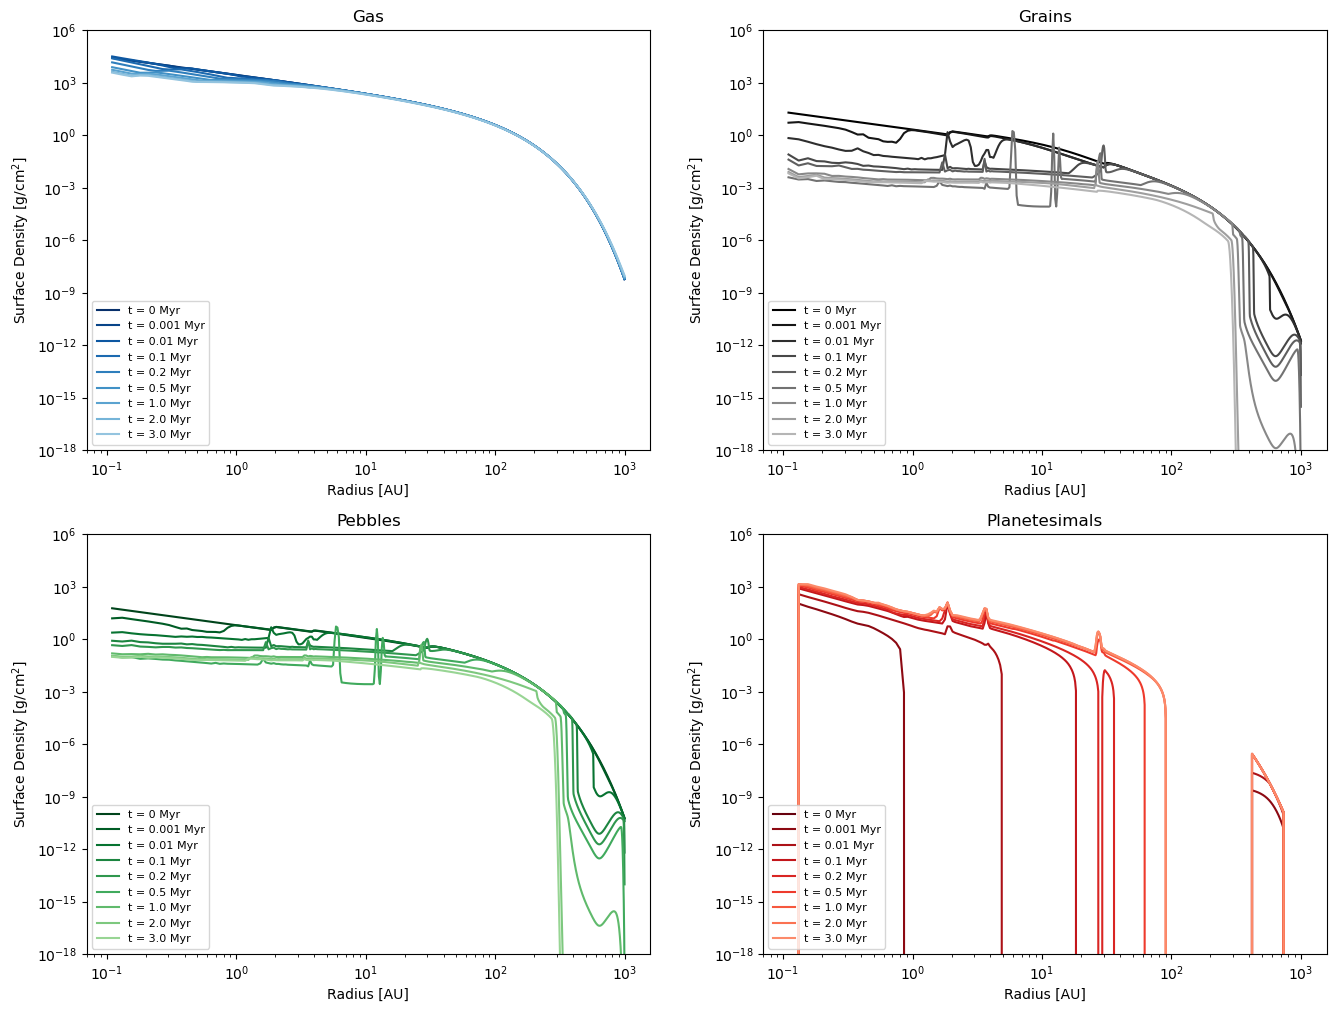

In [222]:
## Plot surface density profiles

n_times = len(t_interval)

fig, ax = plt.subplots(2, 2, figsize = (8 * 2, 6 * 2))

for i in range(n_times):
    ax[0, 0].plot(R, Sigma_G[i], color = color_blues[i], label = f't = {t_interval[i]} Myr')
    ax[0, 1].plot(R, Sigma_grains[i], color = color_greys[i], label = f't = {t_interval[i]} Myr')
    ax[1, 0].plot(R, Sigma_pebble[i], color = color_greens[i], label = f't = {t_interval[i]} Myr')

    if config["planetesimal"]["active"]:
        ax[1, 1].plot(R, Sigma_planetesimal[i], color = color_reds[i], label = f't = {t_interval[i]} Myr')

for i in range(2):
    for j in range(2):
        ax[i, j].set_xscale('log')
        ax[i, j].set_yscale('log')
        ax[i, j].set_xlabel('Radius [AU]')
        ax[i, j].set_ylabel(r'Surface Density [$\rm{g/cm^2}$]')
        ax[i, j].legend(loc = 'lower left', fontsize = 8)
        ax[i, j].set_ylim(1e-18, 1e6)

ax[0, 0].set_title('Gas')
ax[0, 1].set_title('Grains')
ax[1, 0].set_title('Pebbles')
ax[1, 1].set_title('Planetesimals')

plt.show()

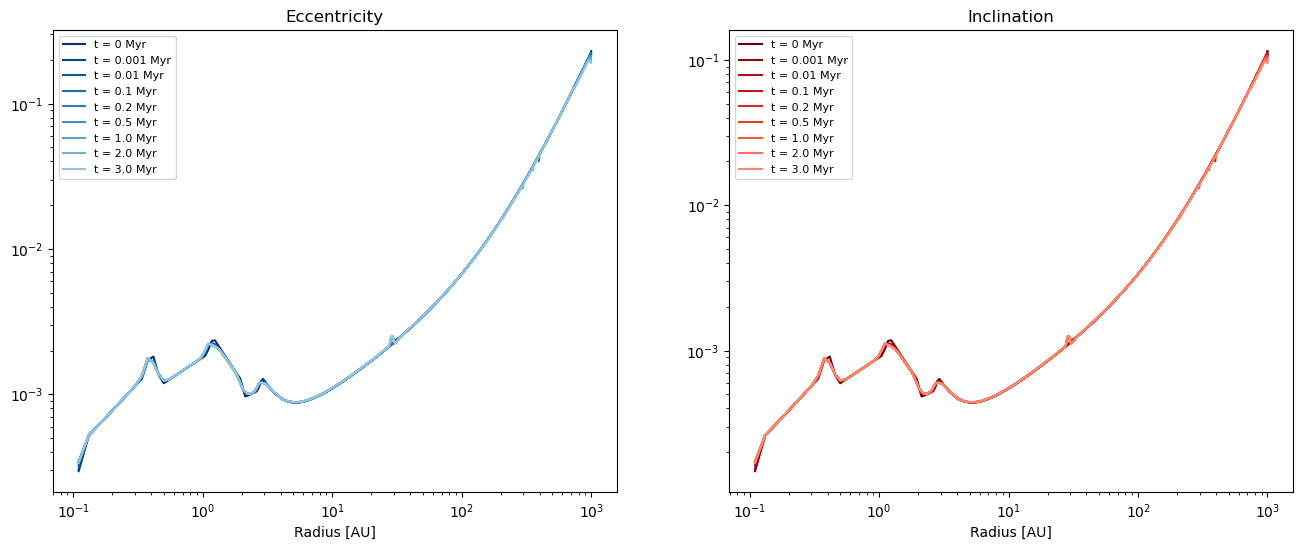

In [223]:
## Plot eccentricity and inclination profiles

n_times = len(t_interval)

fig, ax = plt.subplots(1, 2, figsize = (8 * 2, 6))

for i in range(n_times):
    if config["planetesimal"]["active"]:
        ax[0].plot(R, e_planetesimal[i], color = color_blues[i], label = f't = {t_interval[i]} Myr')
        ax[1].plot(R, i_planetesimal[i], color = color_reds[i], label = f't = {t_interval[i]} Myr')

for i in range(2):
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
    ax[i].set_xlabel('Radius [AU]')
    ax[i].legend(loc = 'upper left', fontsize = 8)

ax[0].set_title('Eccentricity')
ax[1].set_title('Inclination')

plt.show()

/var/folders/w2/q28l_ff13t7b022wprs3j7lc0000gn/T/ipykernel_67971/1567492381.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i].legend(loc = 'lower left', fontsize = 8)


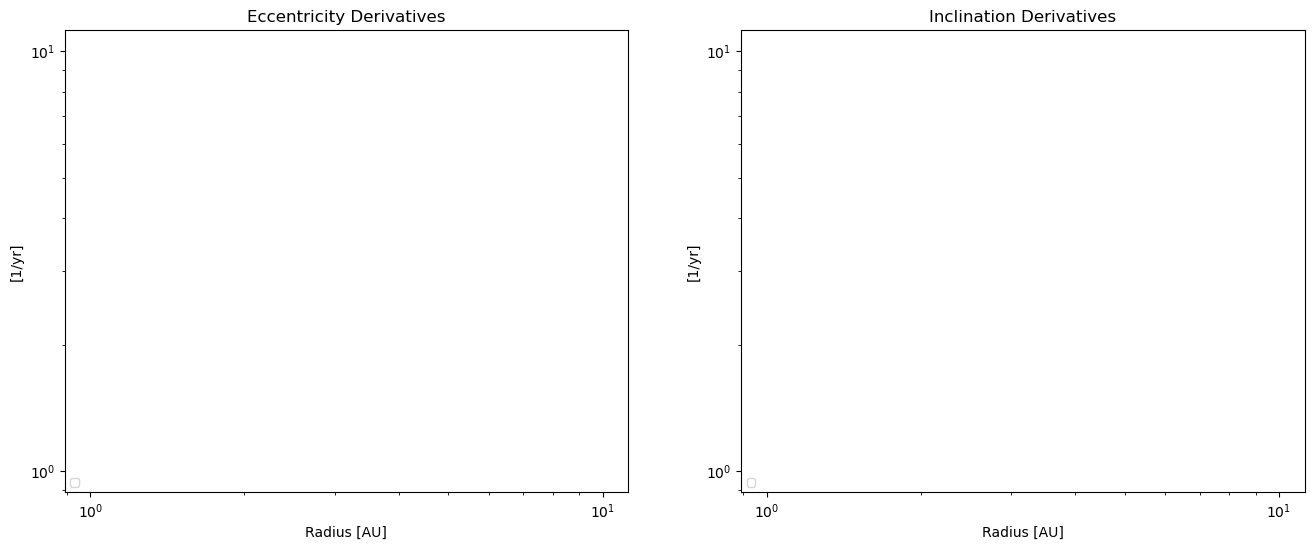

In [224]:
## Plot eccentricity and inclination derivatives

n_times = len(t_interval)

fig, ax = plt.subplots(1, 2, figsize = (8 * 2, 6))

for i in range(n_times):
    if config["planetesimal"]["drag"] or config["planetesimal"]["VS_embryo"] or config["planetesimal"]["VS_pltsml"] or config["planetesimal"]["DF"]:
        ax[0].plot(R, np.where(de2_dt[i] > 0, de2_dt[i], np.nan), color = color_blues[i], linestyle = '-', label = f't = {t_interval[i]} Myr')
        ax[0].plot(R, np.where(de2_dt[i] < 0, -1 * de2_dt[i], np.nan), color = color_blues[i], linestyle = '--')

        ax[1].plot(R, np.where(di2_dt[i] > 0, di2_dt[i], np.nan), color = color_reds[i], linestyle = '-', label = f't = {t_interval[i]} Myr')
        ax[1].plot(R, np.where(di2_dt[i] < 0, -1 * di2_dt[i], np.nan), color = color_reds[i], linestyle = '--')

for i in range(2):
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
    ax[i].set_xlabel('Radius [AU]')
    ax[i].set_ylabel('[1/yr]')
    ax[i].legend(loc = 'lower left', fontsize = 8)

ax[0].set_title('Eccentricity Derivatives')
ax[1].set_title('Inclination Derivatives')

plt.show()

/var/folders/w2/q28l_ff13t7b022wprs3j7lc0000gn/T/ipykernel_67971/3551532091.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend(loc = 'lower left', fontsize = 8)
/var/folders/w2/q28l_ff13t7b022wprs3j7lc0000gn/T/ipykernel_67971/3551532091.py:70: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend(loc = 'lower left', fontsize = 8)


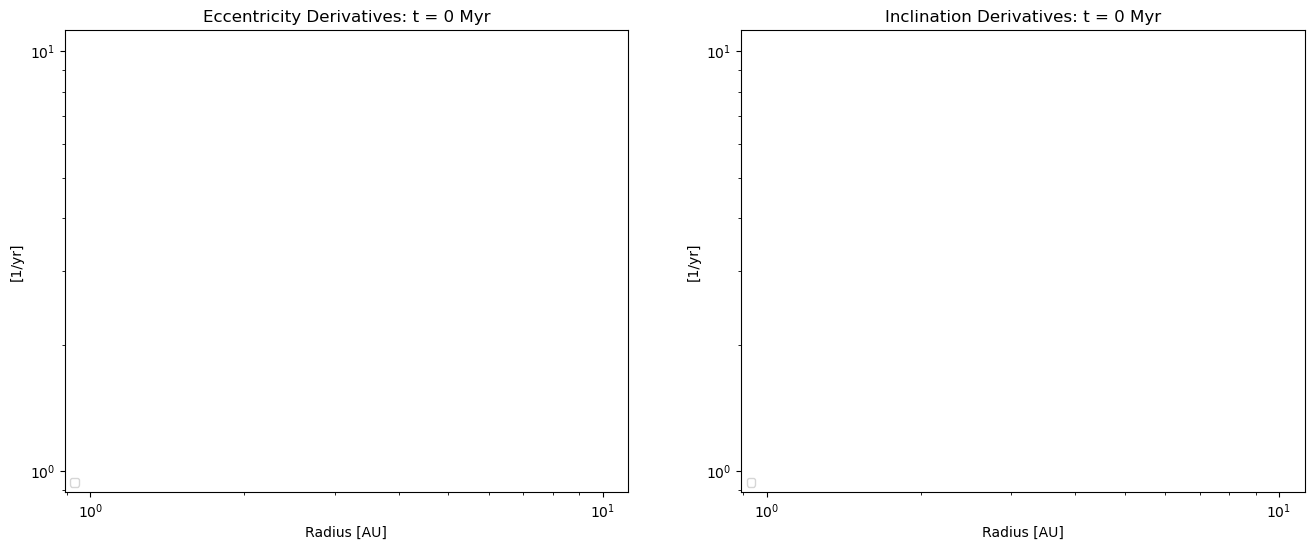

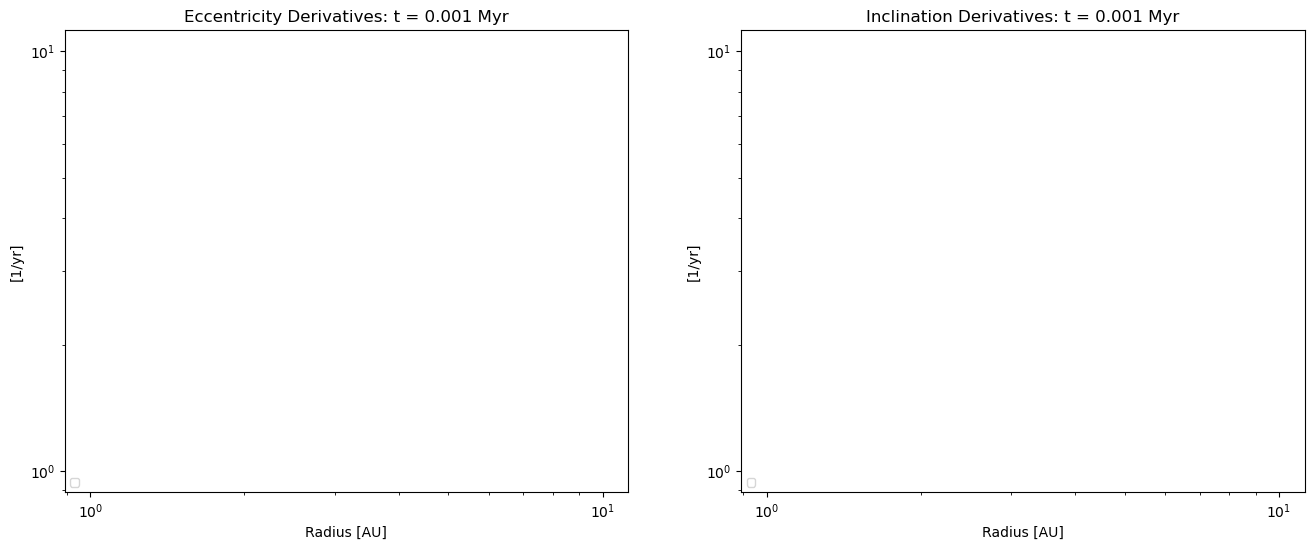

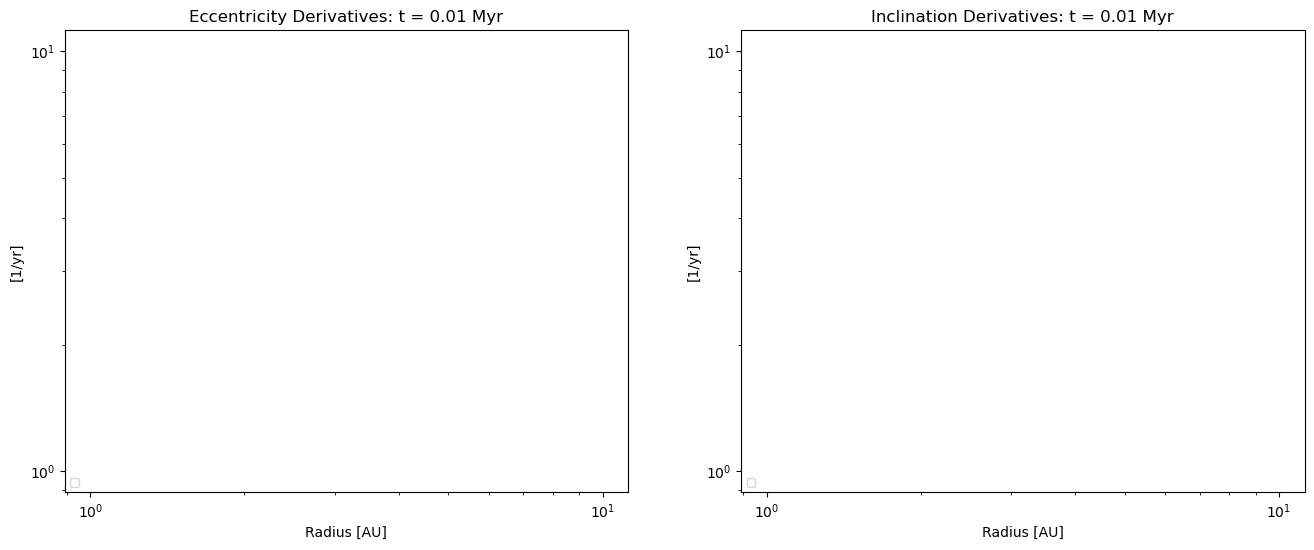

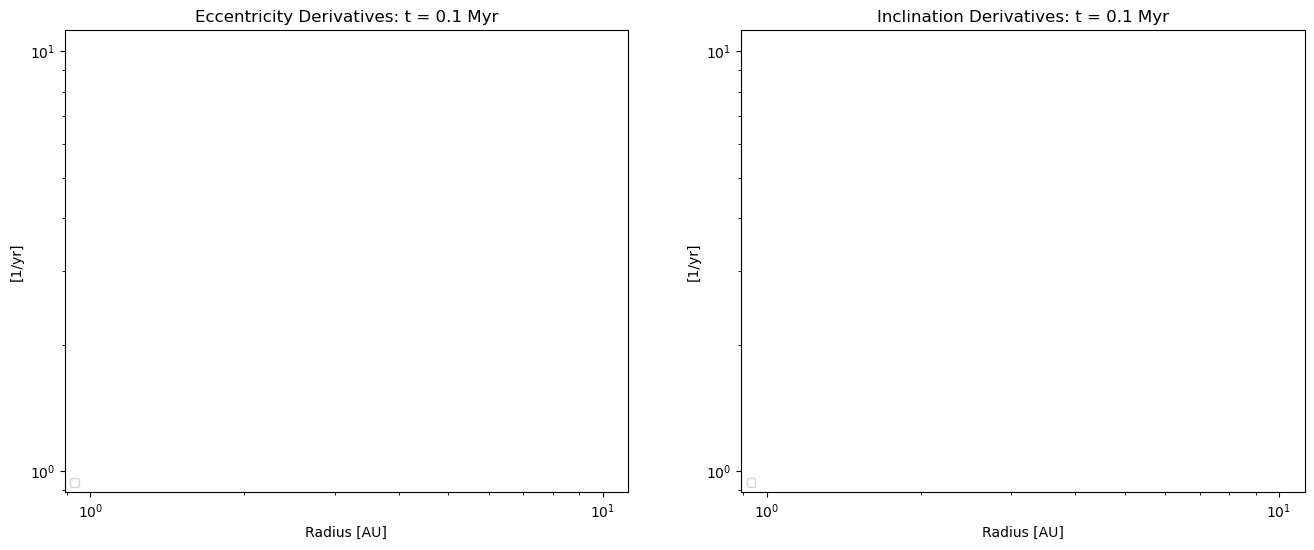

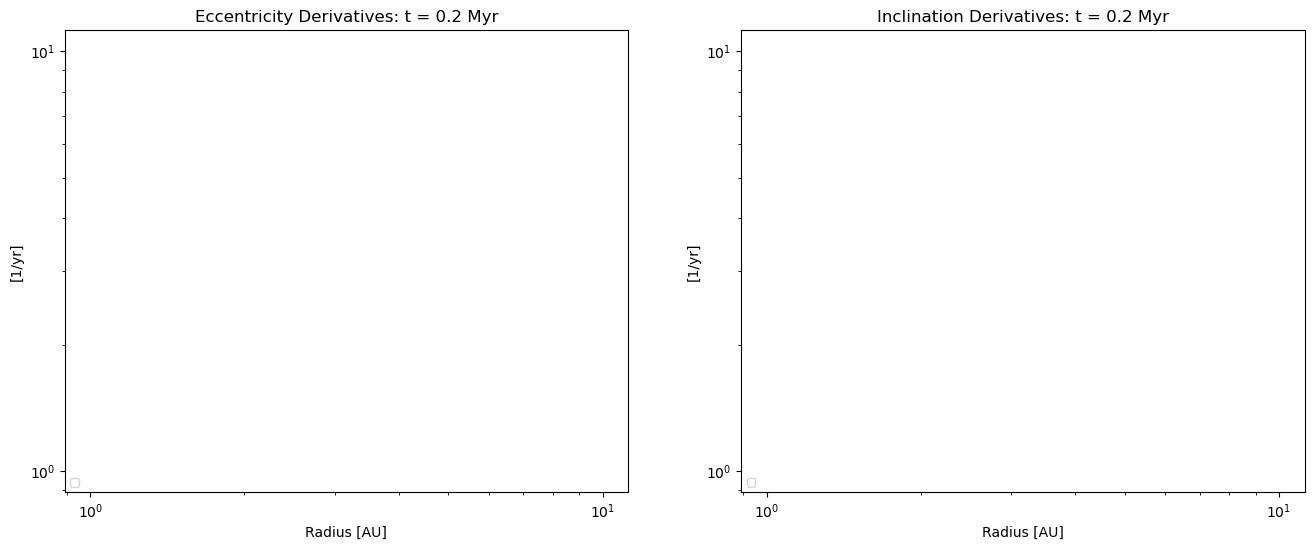

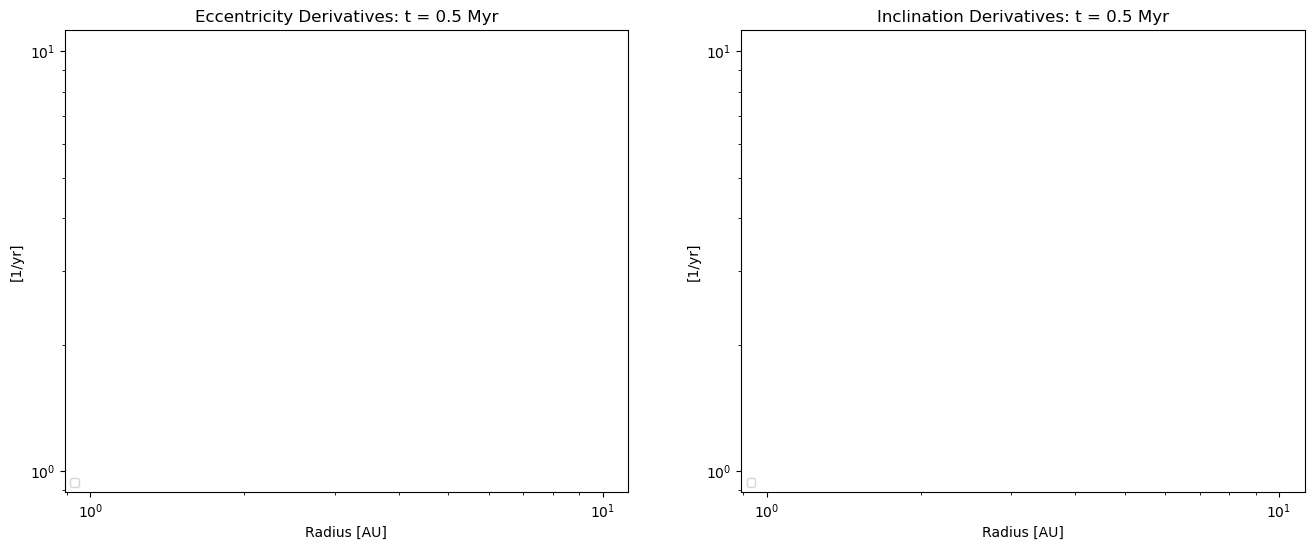

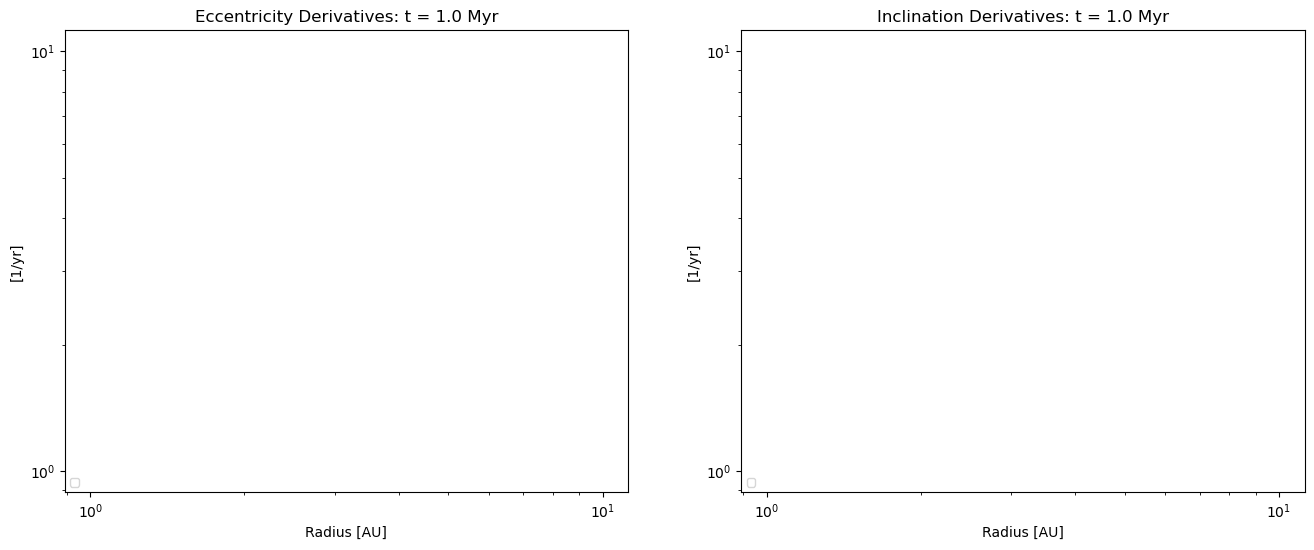

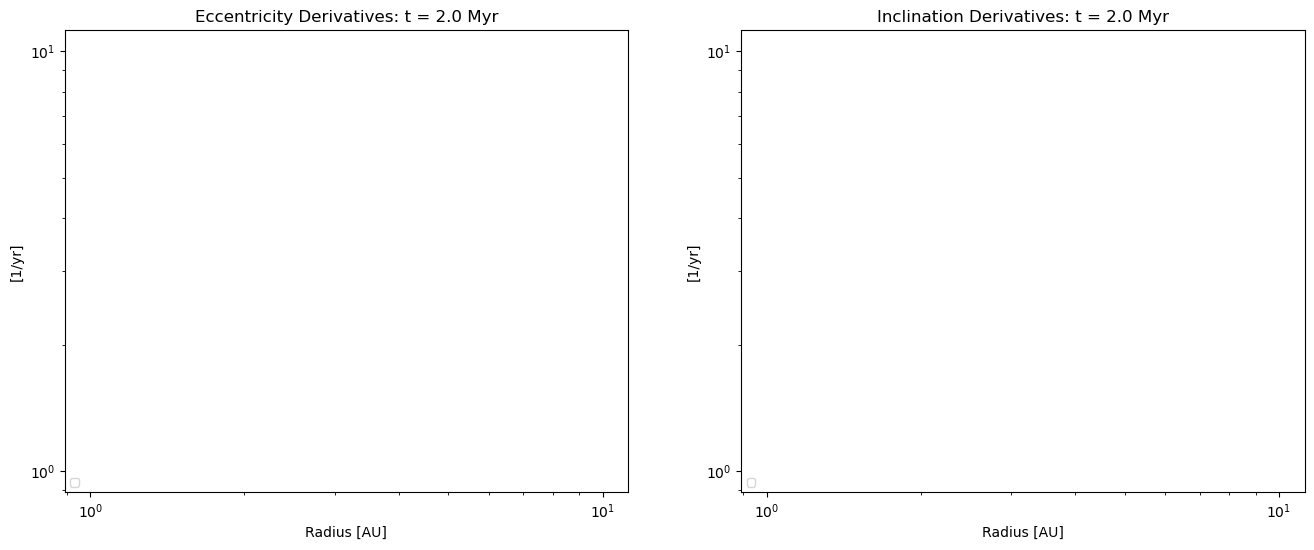

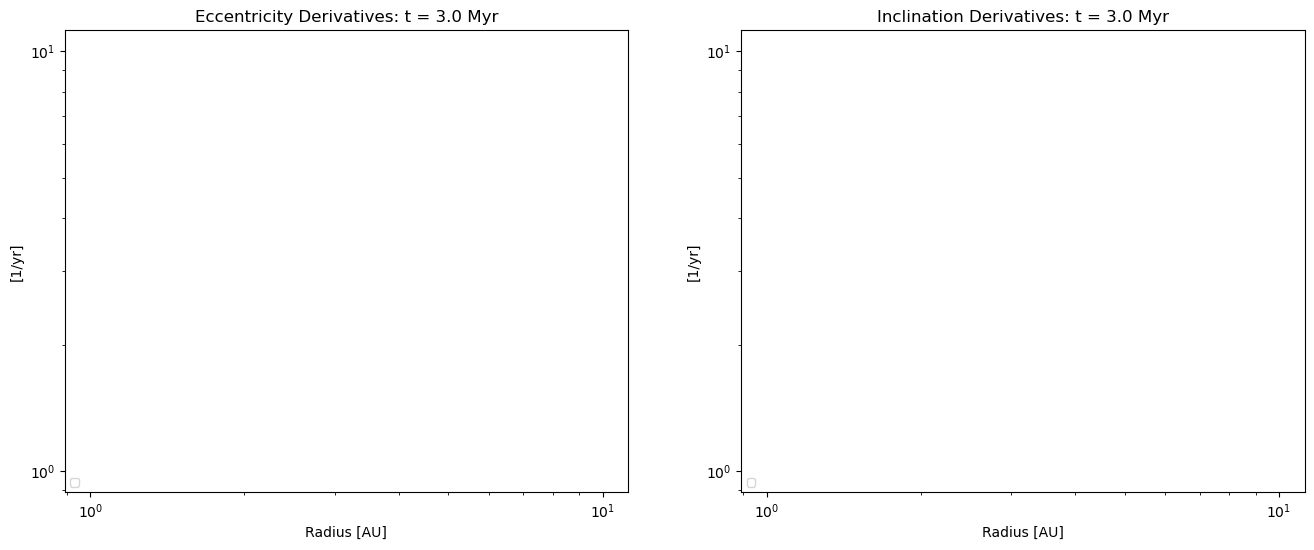

In [225]:
## Plot eccentricity and inclination derivatives

n_times = len(t_interval)

for i in range(n_times):
    fig, ax = plt.subplots(1, 2, figsize = (8 * 2, 6))

    ## Eccentricity derivatives
    if config["planetesimal"]["drag"] or config["planetesimal"]["VS_embryo"] or config["planetesimal"]["VS_pltsml"] or config["planetesimal"]["DF"]:
        ax[0].plot(R, np.where(de2_dt[i] > 0, de2_dt[i], np.nan), color = 'black', linestyle = '-', label = r'$\dot e^2(t)$')
        ax[0].plot(R, np.where(de2_dt[i] < 0, -1 * de2_dt[i], np.nan), color = 'black', linestyle = '--')
    
    ## Drag
    if config["planetesimal"]["drag"]:
        ax[0].plot(R, np.where(de2_dt_drag[i] > 0, de2_dt_drag[i], np.nan), color = 'blue', linestyle = '-', label = 'Drag')
        ax[0].plot(R, np.where(de2_dt_drag[i] < 0, -1 * de2_dt_drag[i], np.nan), color = 'blue', linestyle = '--')

    ## VS_embryo
    if config["planetesimal"]["VS_embryo"]:
        ax[0].plot(R, np.where(de2_dt_VS_embryo[i] > 0, de2_dt_VS_embryo[i], np.nan), color = 'red', linestyle = '-', label = 'Embryo Stirring')
        ax[0].plot(R, np.where(de2_dt_VS_embryo[i] < 0, -1 * de2_dt_VS_embryo[i], np.nan), color = 'red', linestyle = '--')

    ## VS_pltsml
    if config["planetesimal"]["VS_pltsml"]:
        ax[0].plot(R, np.where(de2_dt_VS_pltsml[i] > 0, de2_dt_VS_pltsml[i], np.nan), color = 'orange', linestyle = '-', label = 'Planetesimal Stirring')
        ax[0].plot(R, np.where(de2_dt_VS_pltsml[i] < 0, -1 * de2_dt_VS_pltsml[i], np.nan), color = 'orange', linestyle = '--')

    ## DF
    if config["planetesimal"]["DF"]:
        ax[0].plot(R, np.where(de2_dt_DF[i] > 0, de2_dt_DF[i], np.nan), color = 'green', linestyle = '-', label = 'Density Fluctuations')
        ax[0].plot(R, np.where(de2_dt_DF[i] < 0, -1 * de2_dt_DF[i], np.nan), color = 'green', linestyle = '--')

    ax[0].set_xscale('log')
    ax[0].set_yscale('log')
    ax[0].set_xlabel('Radius [AU]')
    ax[0].set_ylabel('[1/yr]')
    ax[0].set_title(f'Eccentricity Derivatives: t = { t_interval[i]} Myr')
    ax[0].legend(loc = 'lower left', fontsize = 8)

    ## Inclination derivatives
    if config["planetesimal"]["drag"] or config["planetesimal"]["VS_embryo"] or config["planetesimal"]["VS_pltsml"] or config["planetesimal"]["DF"]:
        ax[1].plot(R, np.where(di2_dt[i] > 0, di2_dt[i], np.nan), color = 'black', linestyle = '-', label = r'$\dot i^2(t)$')
        ax[1].plot(R, np.where(di2_dt[i] < 0, -1 * di2_dt[i], np.nan), color = 'black', linestyle = '--')

    ## Drag
    if config["planetesimal"]["drag"]:
        ax[1].plot(R, np.where(di2_dt_drag[i] > 0, di2_dt_drag[i], np.nan), color = 'blue', linestyle = '-', label = 'Drag')
        ax[1].plot(R, np.where(di2_dt_drag[i] < 0, -1 * di2_dt_drag[i], np.nan), color = 'blue', linestyle = '--')

    ## VS_embryo
    if config["planetesimal"]["VS_embryo"]:
        ax[1].plot(R, np.where(di2_dt_VS_embryo[i] > 0, di2_dt_VS_embryo[i], np.nan), color = 'red', linestyle = '-', label = 'Embryo Stirring')
        ax[1].plot(R, np.where(di2_dt_VS_embryo[i] < 0, -1 * di2_dt_VS_embryo[i], np.nan), color = 'red', linestyle = '--')

    ## VS_pltsml
    if config["planetesimal"]["VS_pltsml"]:
        ax[1].plot(R, np.where(di2_dt_VS_pltsml[i] > 0, di2_dt_VS_pltsml[i], np.nan), color = 'orange', linestyle = '-', label = 'Planetesimal Stirring')
        ax[1].plot(R, np.where(di2_dt_VS_pltsml[i] < 0, -1 * di2_dt_VS_pltsml[i], np.nan), color = 'orange', linestyle = '--')

    ## DF
    if config["planetesimal"]["DF"]:
        ax[1].plot(R, np.where(di2_dt_DF[i] > 0, di2_dt_DF[i], np.nan), color = 'green', linestyle = '-', label = 'Density Fluctuations')
        ax[1].plot(R, np.where(di2_dt_DF[i] < 0, -1 * di2_dt_DF[i], np.nan), color = 'green', linestyle = '--')

    ax[1].set_xscale('log')
    ax[1].set_yscale('log')
    ax[1].set_xlabel('Radius [AU]')
    ax[1].set_ylabel('[1/yr]')
    ax[1].set_title(f'Inclination Derivatives: t = { t_interval[i]} Myr')
    ax[1].legend(loc = 'lower left', fontsize = 8)


In [226]:
## Method to cumulatively integrate an accretion rate over time

def cumulative_mass_accreted(t, Mdot):
    """
    Cumulatively integrate the accretion rate over time to give accreted mass at each timestep.

    Parameters:
        t: Array of times, shape (n_times).
        Mdot: Array of accretion rates, shape (n_times) or (n_planets, n_times).

    Returns:
        Array of the same shape as Mdot giving the cumulative mass accreted up to each timestep.
    """

    M = [0.0]

    for k in range(len(t) - 1):
        dt = t[k + 1] - t[k]
        M.append(M[-1] + Mdot[k] * dt)

    return np.array(M)

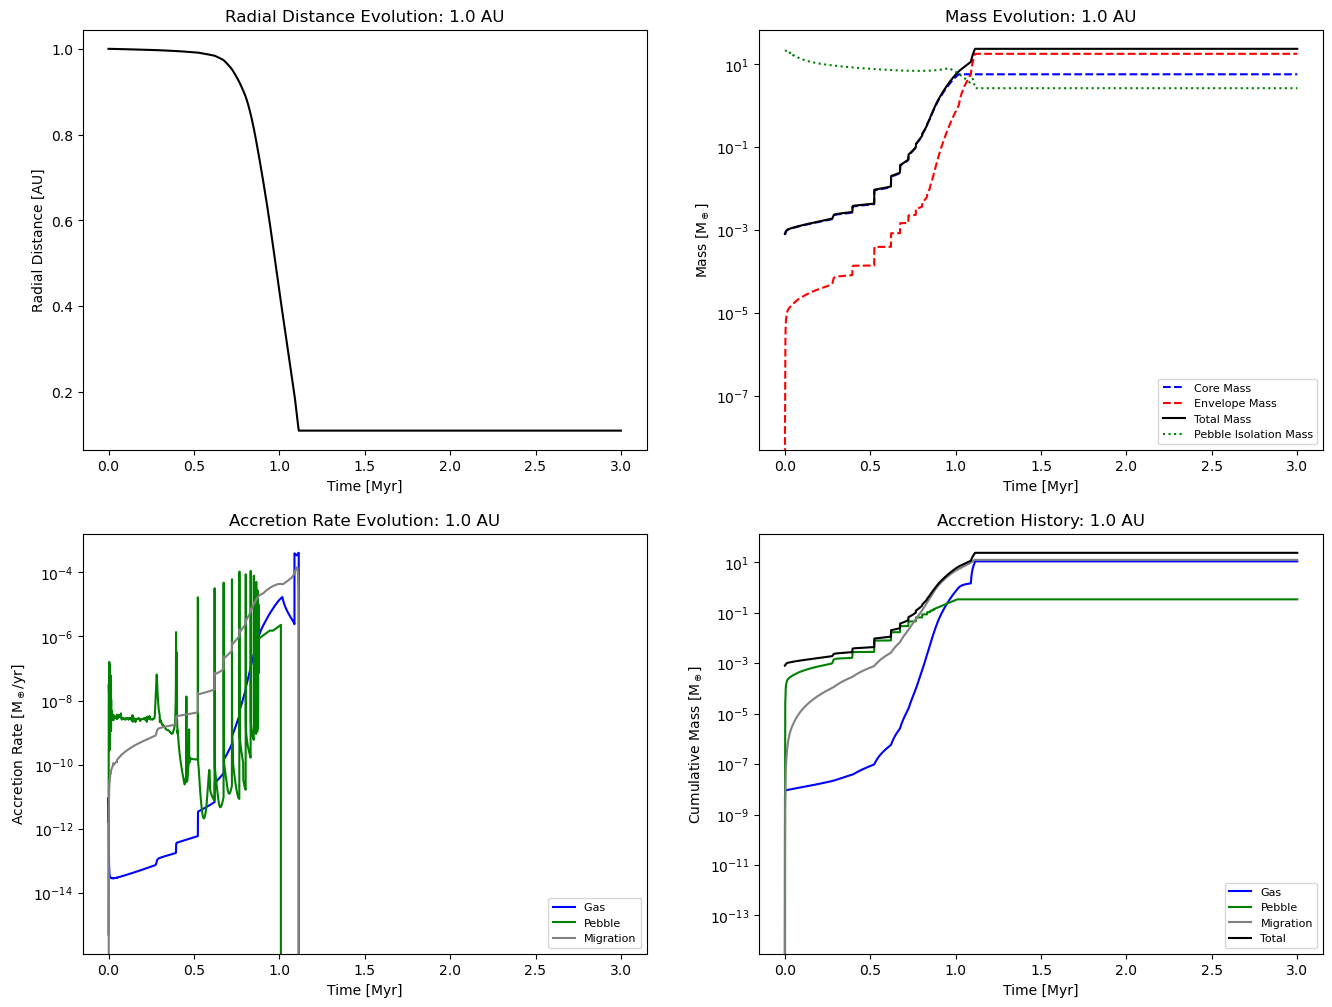

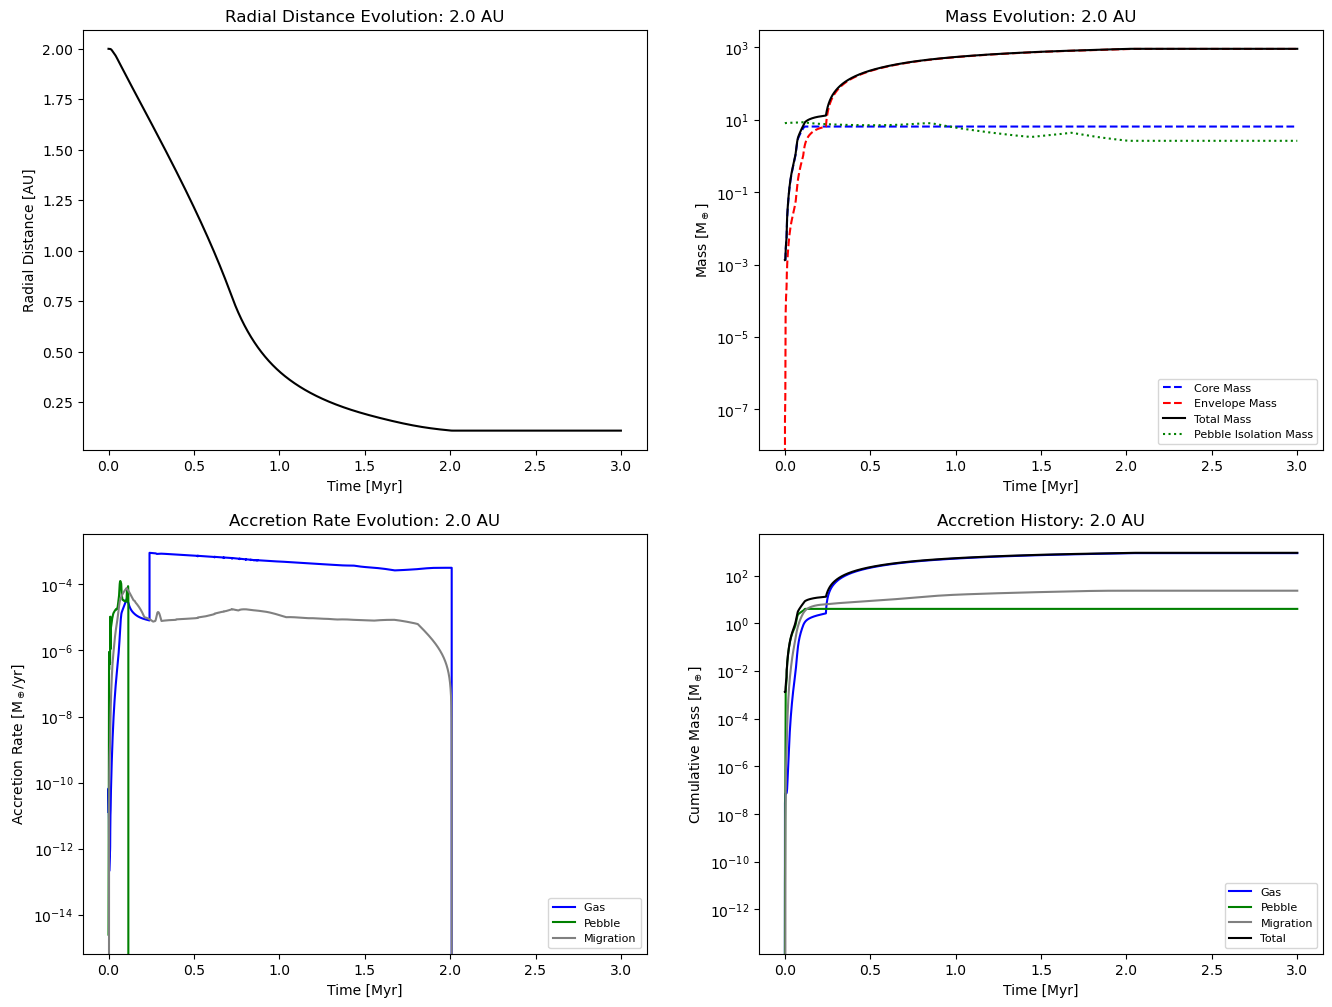

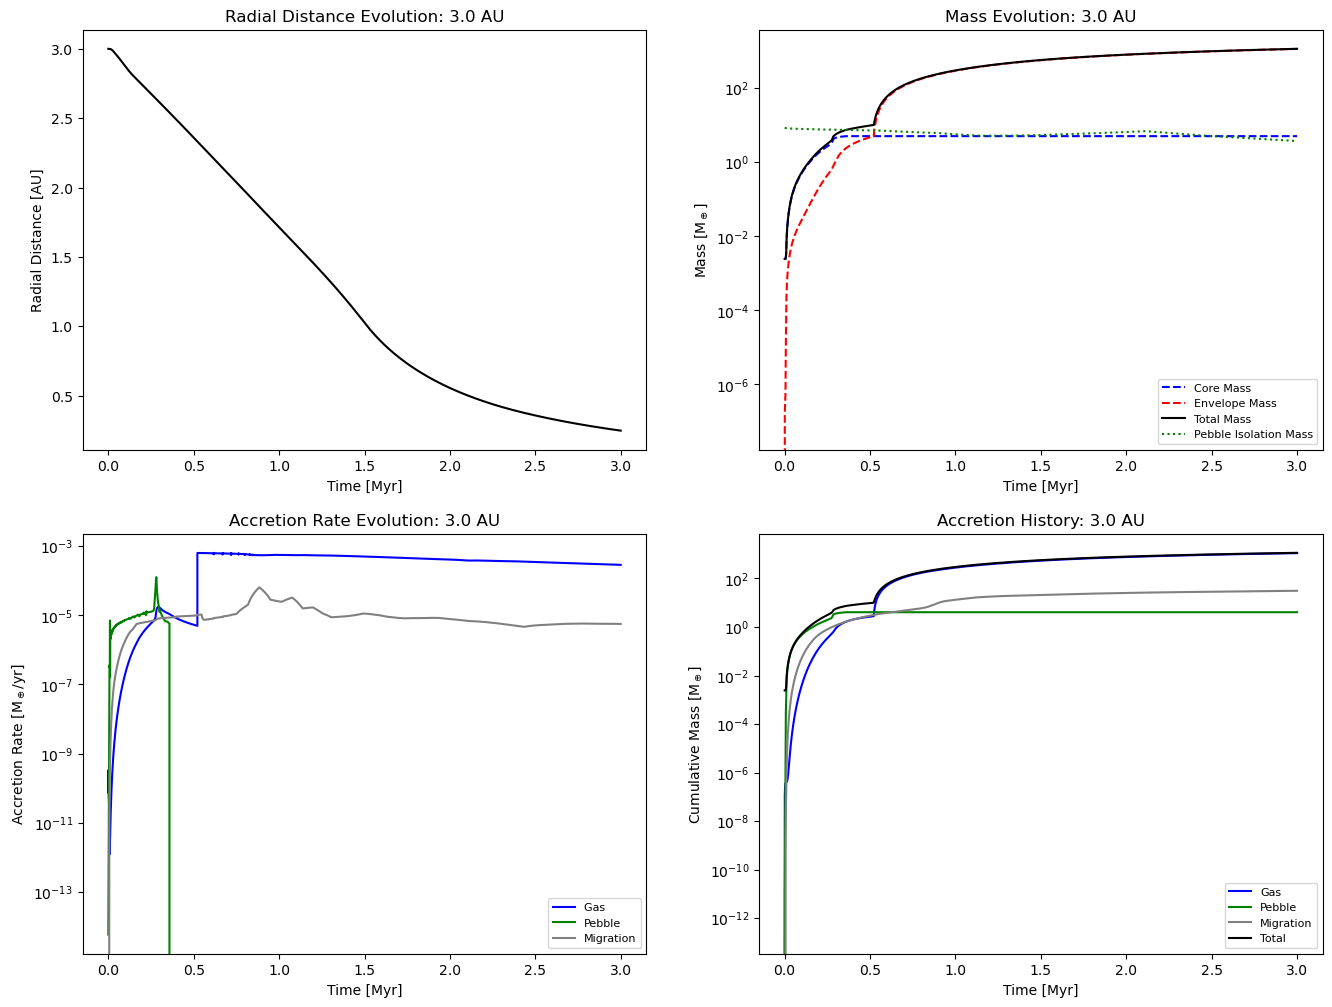

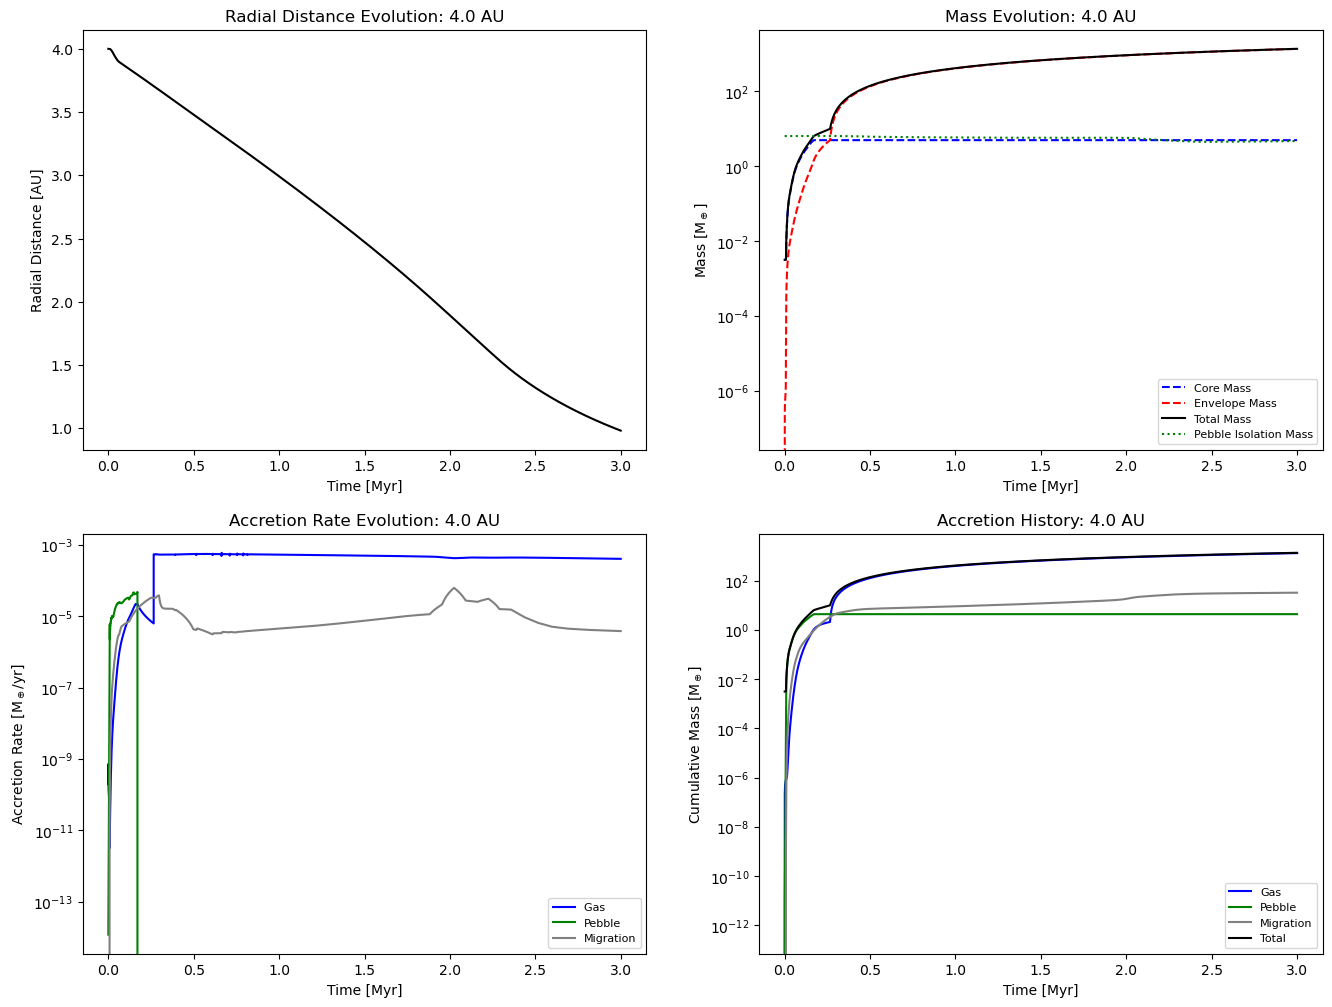

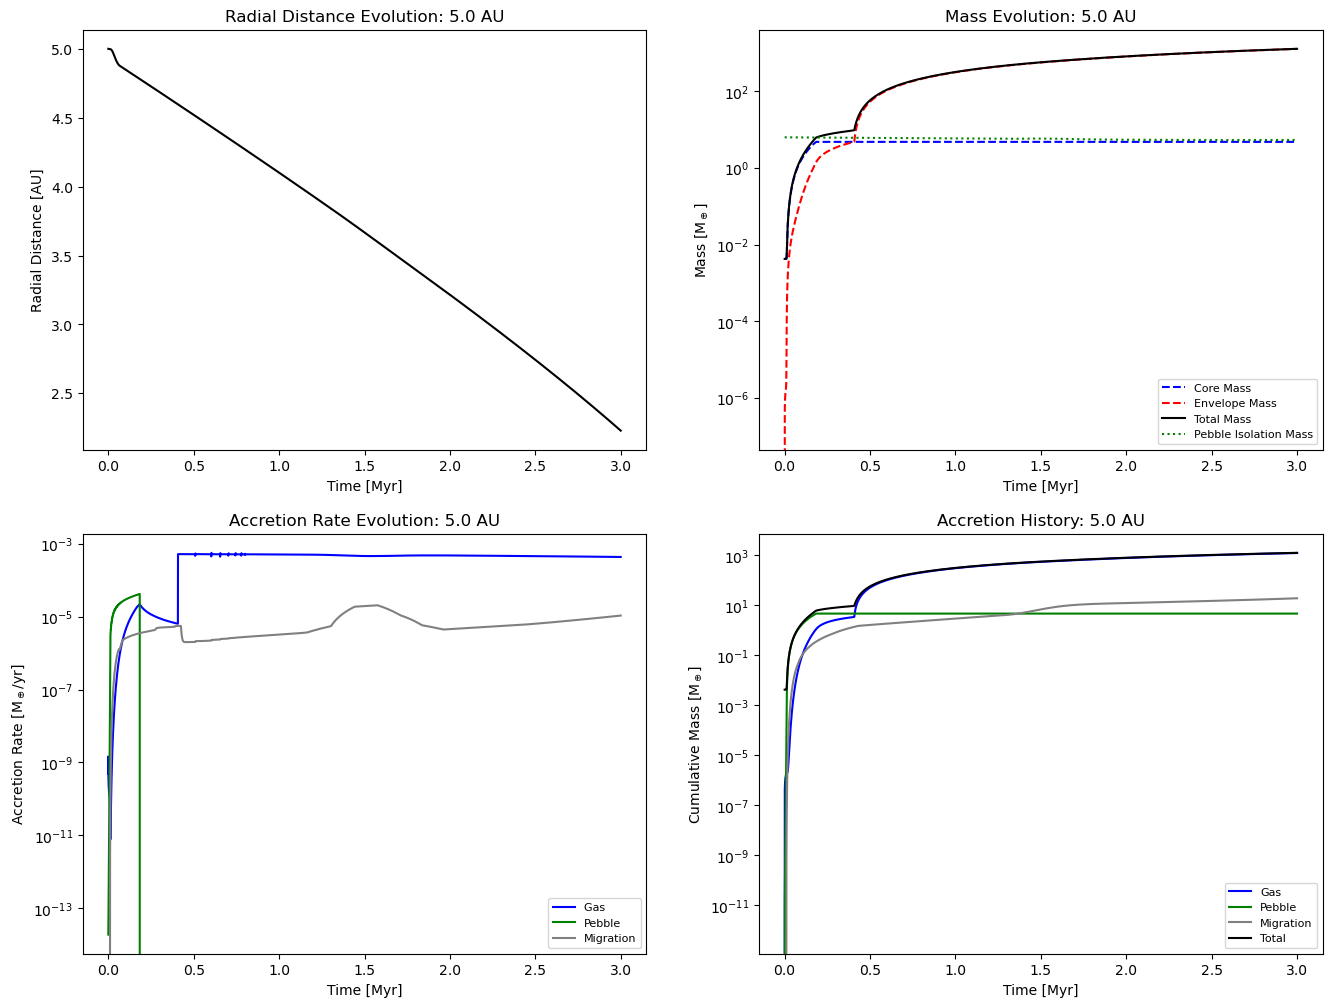

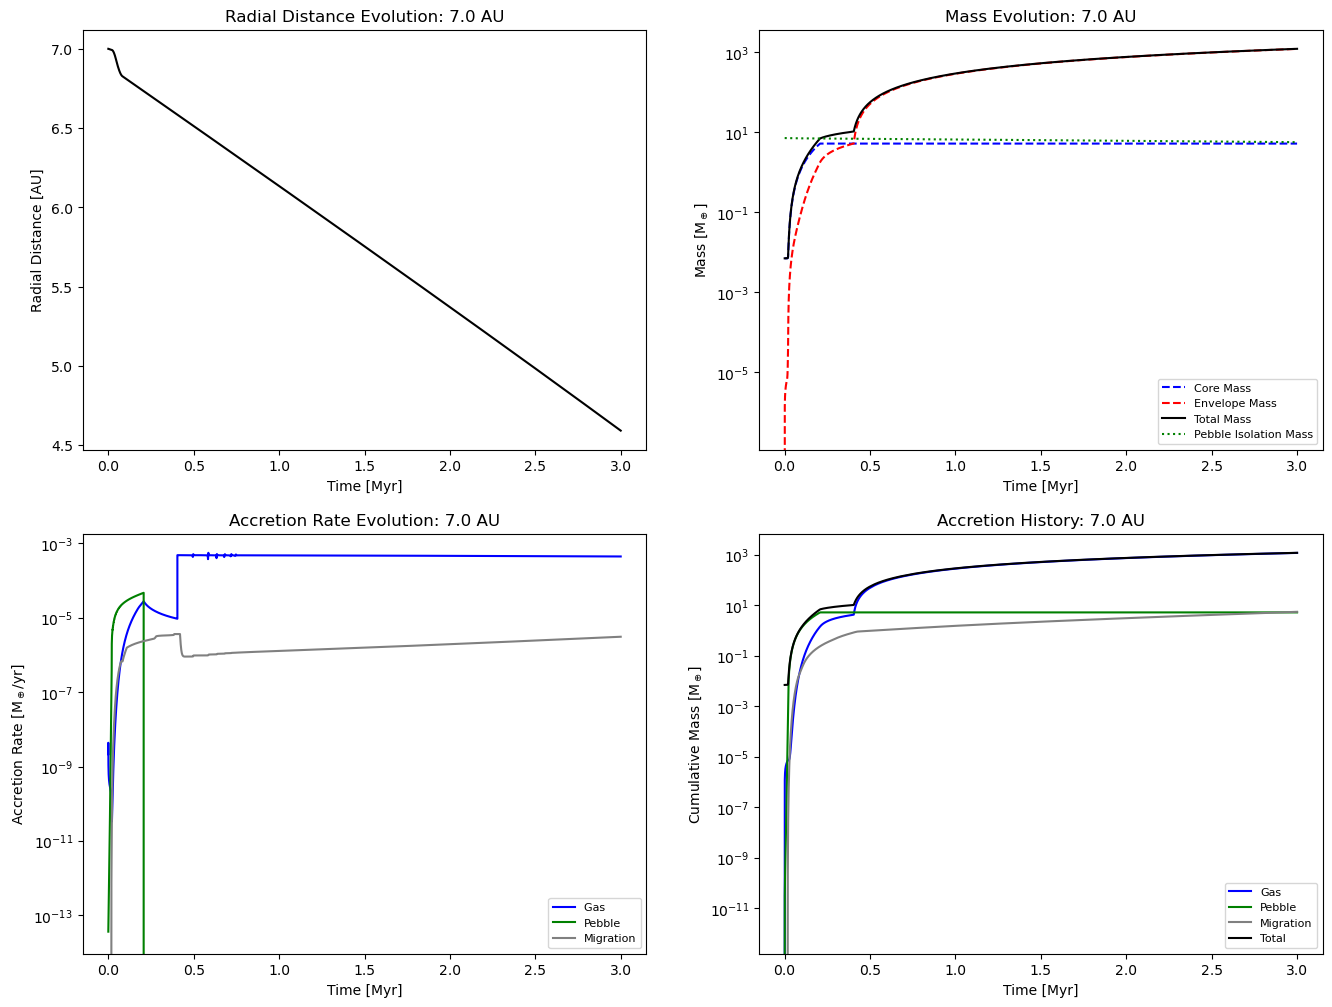

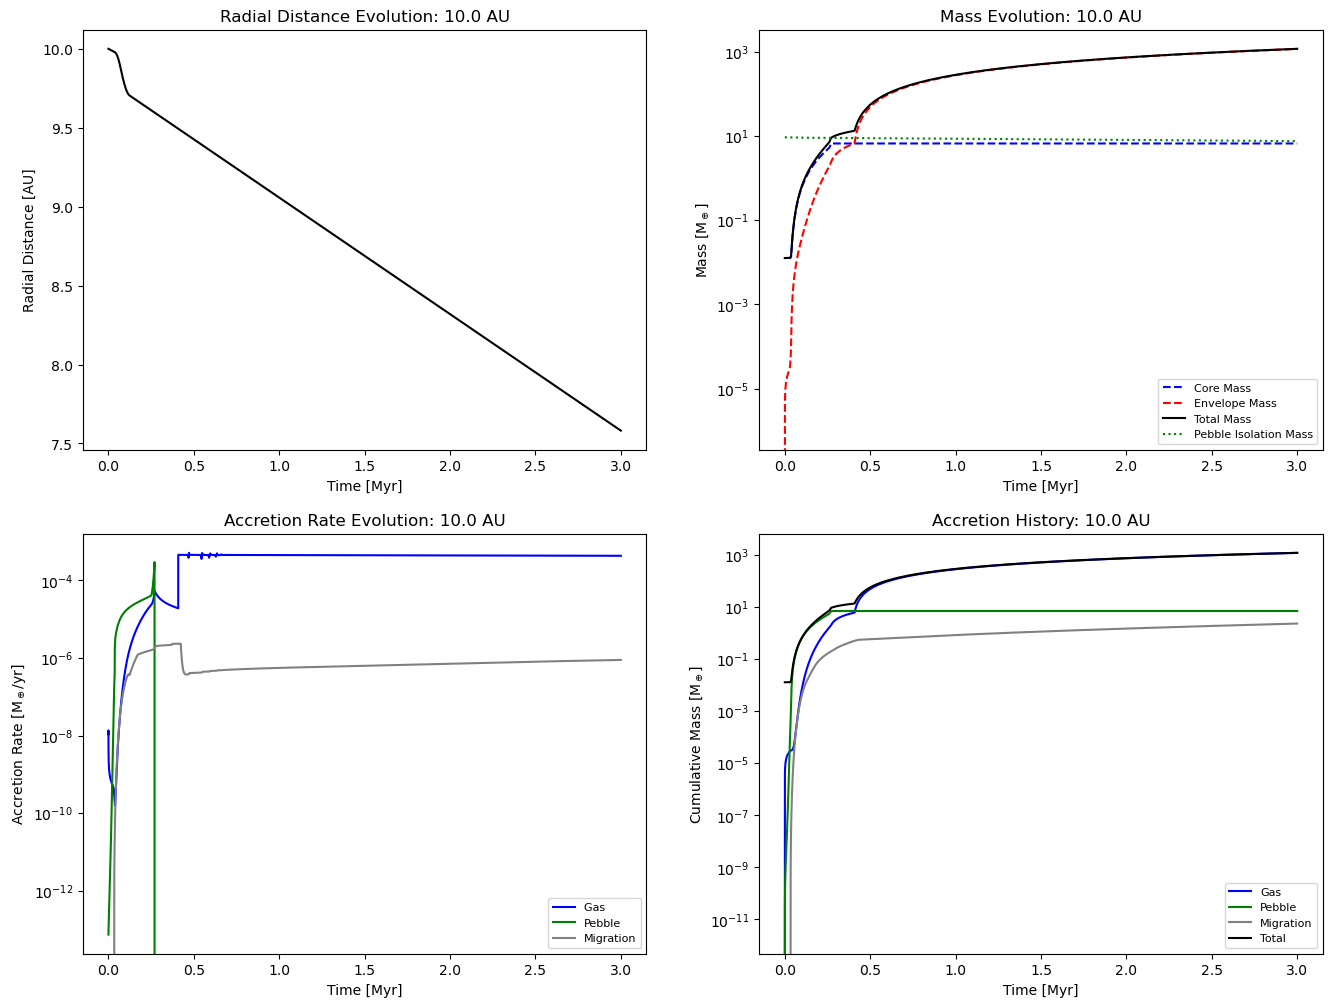

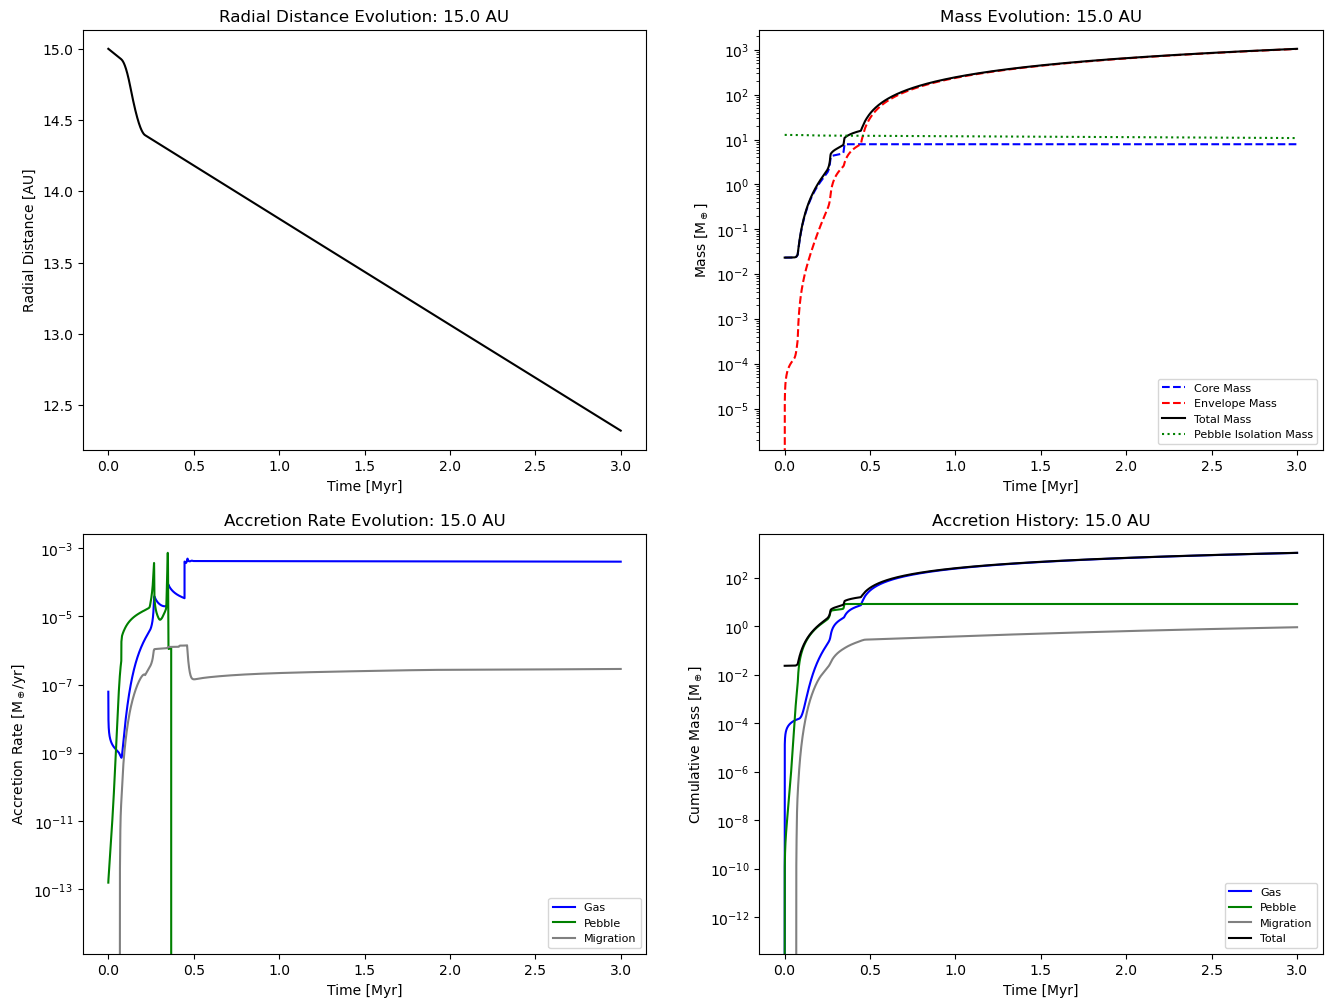

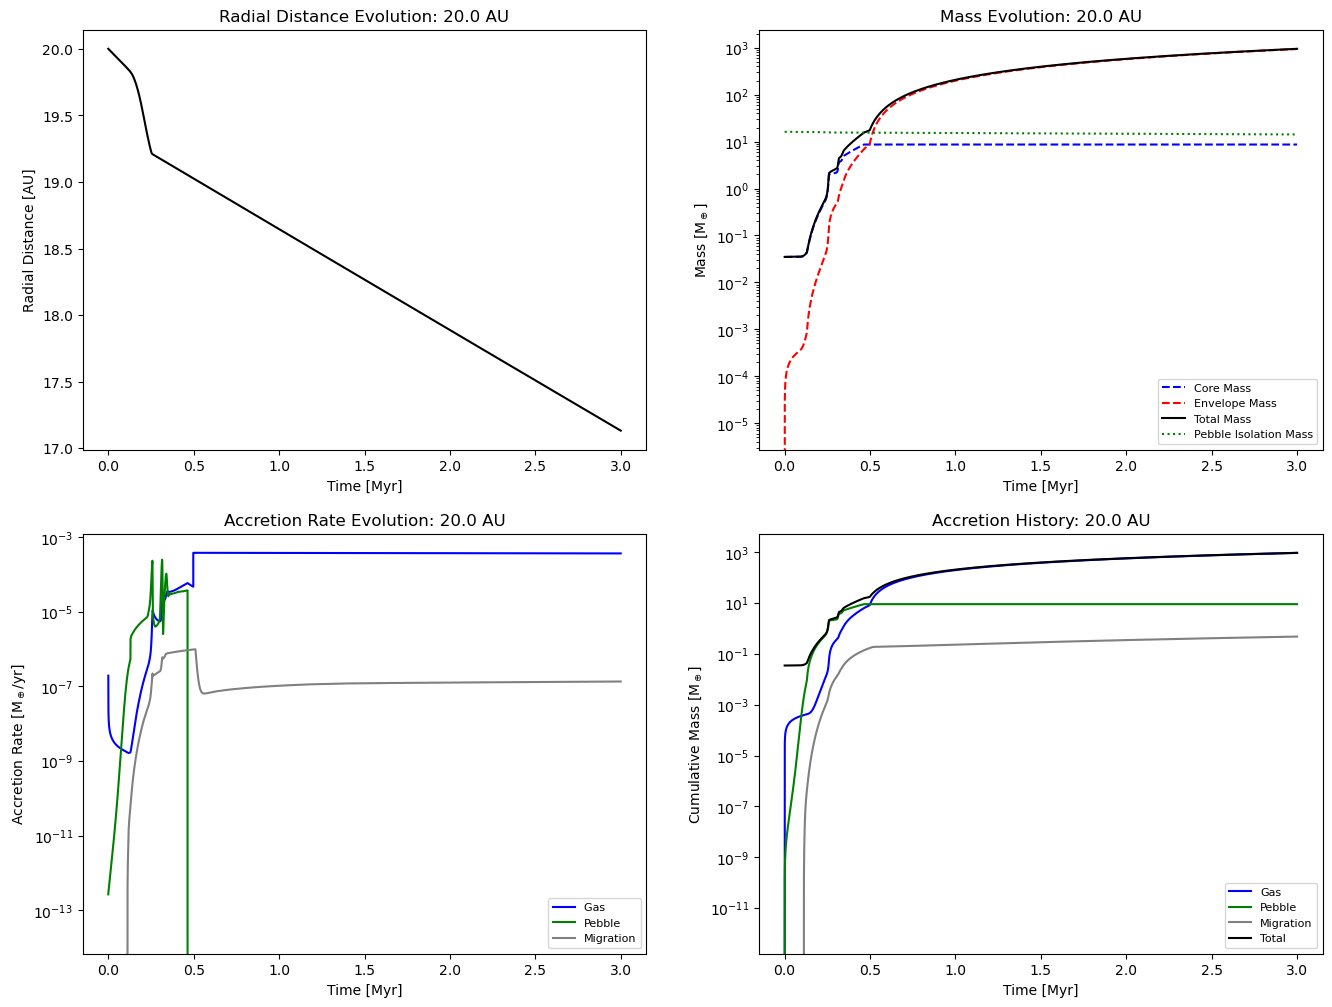

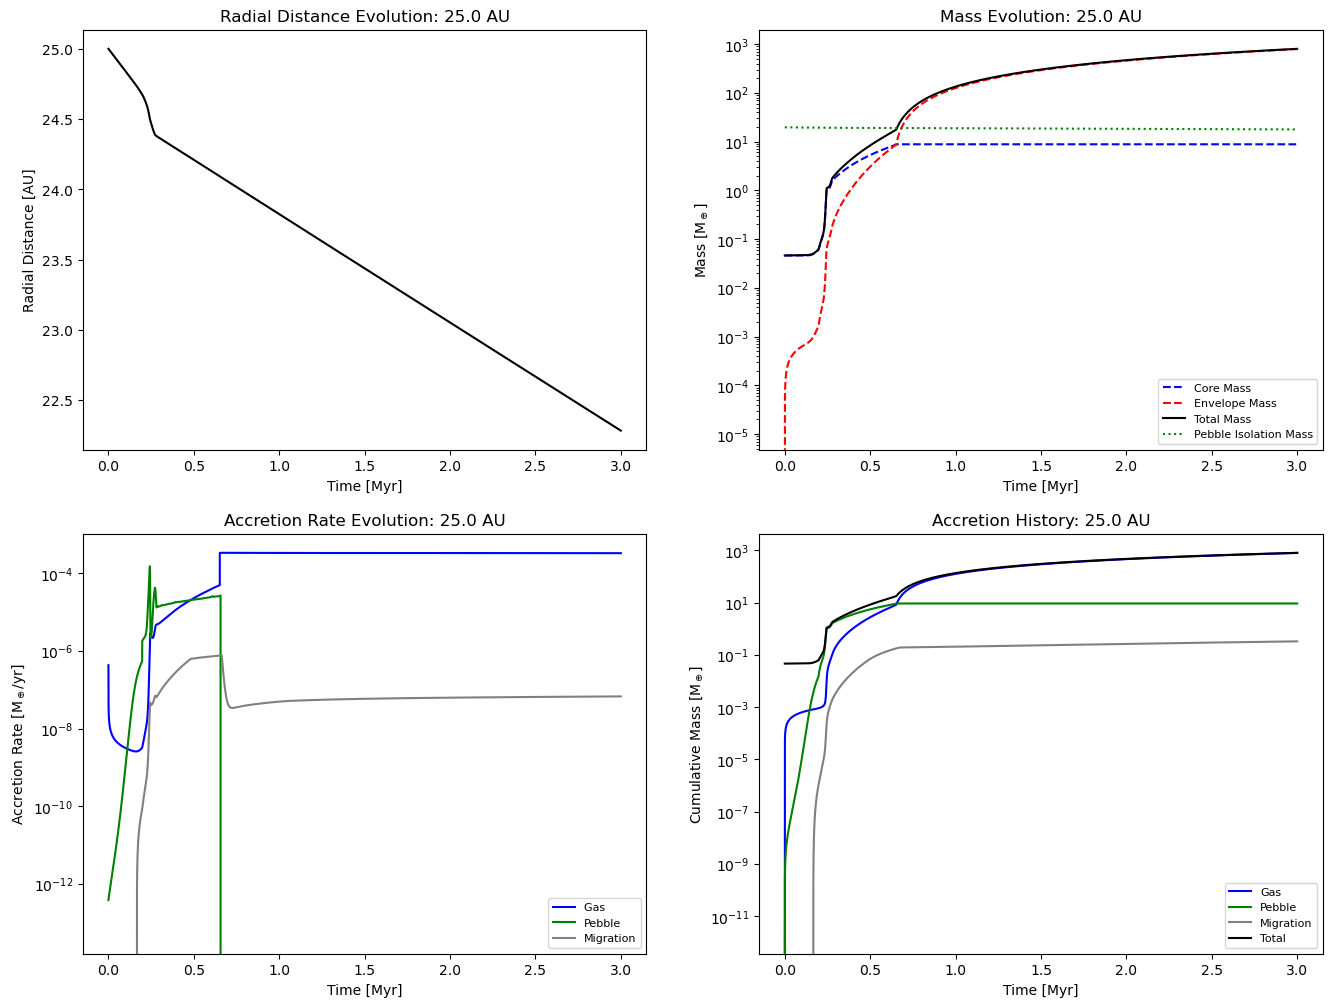

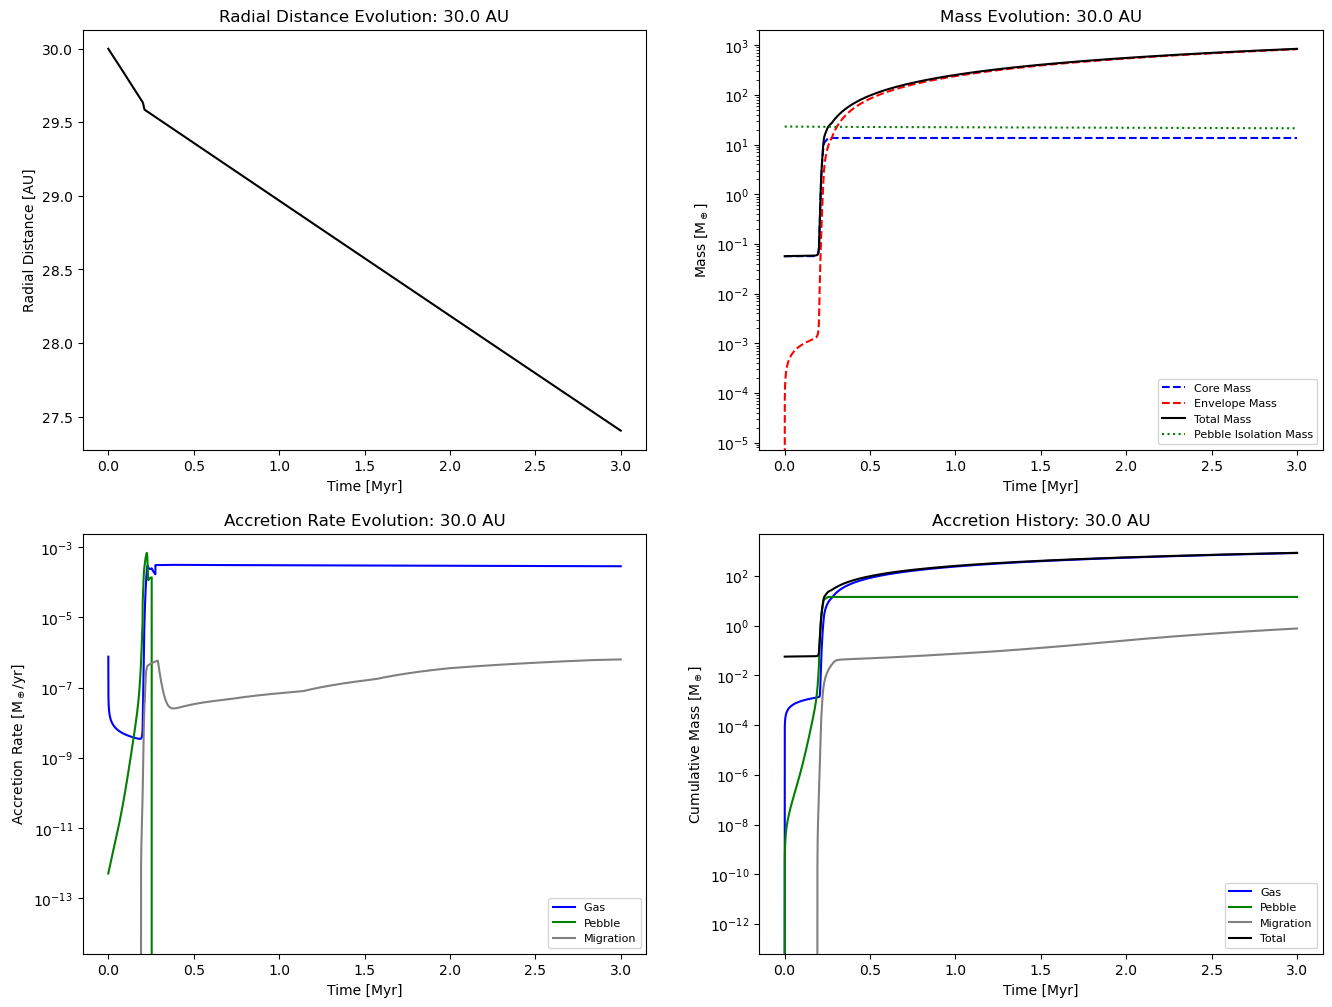

In [227]:
## Plot mass, accretion rate, and radial distance evolution of the planet

n_planets = len(Rp)

for i in range(n_planets):
    fig, ax = plt.subplots(2, 2, figsize = (8 * 2, 6 * 2))

    ## Radial distance evolution

    ax[0, 0].plot(t / 1e6, Rp[i], color = 'black')

    ax[0, 0].set_xlabel('Time [Myr]')
    ax[0, 0].set_ylabel('Radial Distance [AU]')
    ax[0, 0].set_title(f'Radial Distance Evolution: {Rp[i][0]} AU')

    ## Mass evolution

    ax[0, 1].plot(t / 1e6, Mcs[i], color = 'blue', linestyle = '--', label = f'Core Mass')
    ax[0, 1].plot(t / 1e6, Mes[i], color = 'red', linestyle = '--', label = f'Envelope Mass')
    ax[0, 1].plot(t / 1e6, Mcs[i] + Mes[i], color = 'black', label = f'Total Mass')

    if config["planets"]["planetesimal_accretion_insitu"]:
        ax[0, 1].plot(t / 1e6, M_iso_planetesimal[i], color = 'grey', linestyle = ':', label = f'Planetesimal Isolation Mass')

    if config["planets"]["pebble_accretion"]:
        ax[0, 1].plot(t / 1e6, M_iso_pebble[i], color = 'green',  linestyle = ':', label = f'Pebble Isolation Mass')

    ax[0, 1].set_yscale('log')
    ax[0, 1].set_xlabel('Time [Myr]')
    ax[0, 1].set_ylabel(r'Mass [M$_\oplus$]')
    ax[0, 1].set_title(f'Mass Evolution: {Rp[i][0]} AU')
    ax[0, 1].legend(loc = 'lower right', fontsize = 8)

    ## Accretion rate evolution

    if config["planets"]["gas_accretion"]:
        ax[1, 0].plot(t / 1e6, Mdot_gas[i], color = 'blue', label = f'Gas ')

    if config["planets"]["pebble_accretion"]:
        ax[1, 0].plot(t / 1e6, Mdot_pebble_core[i] + Mdot_pebble_env[i], color = 'green', label = f'Pebble')

    if config["planets"]["planetesimal_accretion_insitu"]:
        ax[1, 0].plot(t / 1e6, Mdot_planetesimal[i], color = 'red', label = f'Planetesimal')

    if config["planets"]["planetesimal_accretion_migrate"]:
        ax[1, 0].plot(t / 1e6, Mdot_migration[i], color = 'grey', label = f'Migration')

    ax[1, 0].set_yscale('log')
    ax[1, 0].set_xlabel('Time [Myr]')
    ax[1, 0].set_ylabel(r'Accretion Rate [M$_\oplus$/yr]')
    ax[1, 0].set_title(f'Accretion Rate Evolution: {Rp[i][0]} AU')
    ax[1, 0].legend(loc = 'lower right', fontsize = 8)

    ## Cumulative mass accreted

    M0 = Mcs[i][0] + Mes[i][0]
    M_tot = np.full_like(t, M0)

    if config["planets"]["gas_accretion"]:
        M_gas_accreted = cumulative_mass_accreted(t, Mdot_gas[i])
        ax[1, 1].plot(t / 1e6, M_gas_accreted, color = 'blue', label = f'Gas')
        M_tot += M_gas_accreted

    if config["planets"]["pebble_accretion"]:
        M_pebble_accreted = cumulative_mass_accreted(t, Mdot_pebble_core[i] + Mdot_pebble_env[i])
        ax[1, 1].plot(t / 1e6, M_pebble_accreted, color = 'green', label = f'Pebble')
        M_tot += M_pebble_accreted

    if config["planets"]["planetesimal_accretion_insitu"]:
        M_planetesimal_accreted = cumulative_mass_accreted(t, Mdot_planetesimal[i])
        ax[1, 1].plot(t / 1e6, M_planetesimal_accreted, color = 'red', label = f'Planetesimal')
        M_tot += M_planetesimal_accreted

    if config["planets"]["planetesimal_accretion_migrate"]:
        M_migration_accreted = cumulative_mass_accreted(t, Mdot_migration[i])
        ax[1, 1].plot(t / 1e6, M_migration_accreted, color = 'grey', label = f'Migration')
        M_tot += M_migration_accreted

    ax[1, 1].plot(t / 1e6, M_tot, color = 'black', label = f'Total')

    ax[1, 1].set_yscale('log')
    ax[1, 1].set_xlabel('Time [Myr]')
    ax[1, 1].set_ylabel(r'Cumulative Mass [M$_\oplus$]')
    ax[1, 1].set_title(f'Accretion History: {Rp[i][0]} AU')
    ax[1, 1].legend(loc = 'lower right', fontsize = 8)

    plt.show()

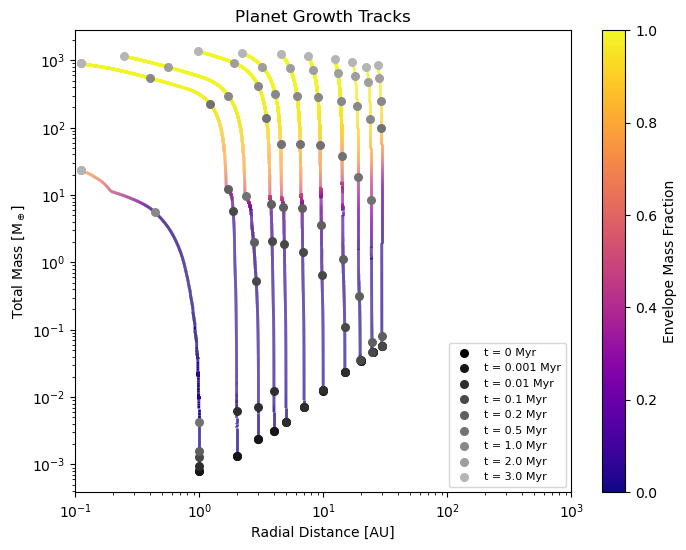

In [228]:
## Plot planet growth tracks, colored by envelope-to-core mass fraction

from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

n_planets = len(Rp)
n_times = len(t_interval)

fig, ax = plt.subplots(figsize = (8, 6))

cmap = plt.get_cmap('plasma')
norm = Normalize(vmin = 0, vmax = 1)

for i in range(n_planets):
    x = Rp[i]
    y = Mcs[i] + Mes[i]
    frac = Mes[i] / y

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis = 1)

    lc = LineCollection(segments, cmap = cmap, norm = norm)
    lc.set_array(frac)
    lc.set_linewidth(2)
    line = ax.add_collection(lc)

    for j in range(n_times):
        k = np.array([np.argmin(np.abs(t / 1e6 - t_interval[j]))])

        if i == 0:
            label = f't = {t_interval[j]} Myr'
            
        else:
            label = None

        ax.scatter(Rp[i][k], y[k], color = color_greys[j], s = 30, zorder = 3, label = label)

ax.set_xlim(1e-1, 1e3)
ax.set_xscale('log')
ax.set_yscale('log')
ax.autoscale_view(scalex = False, scaley = True)
ax.set_xlabel('Radial Distance [AU]')
ax.set_ylabel(r'Total Mass [M$_\oplus$]')
ax.set_title('Planet Growth Tracks')

cbar = fig.colorbar(line, ax = ax)
cbar.set_label('Envelope Mass Fraction')

plt.legend(loc = 'lower right', fontsize = 8)

plt.show()

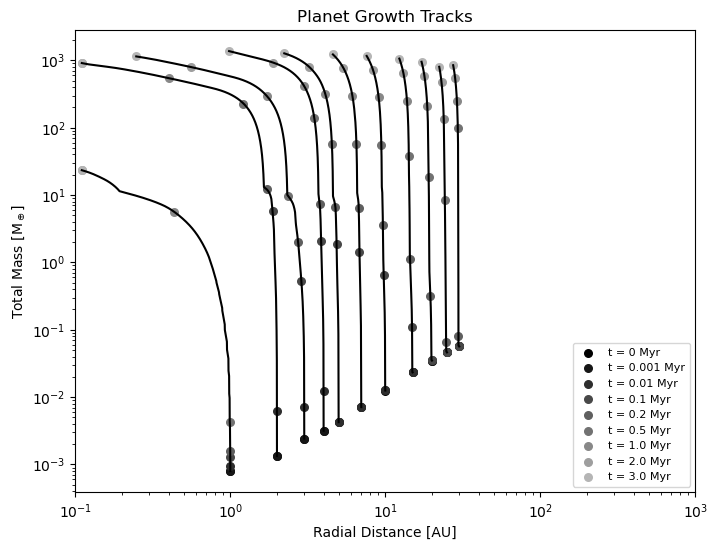

In [229]:
## Plot planet growth tracks

n_planets = len(Rp)
n_times = len(t_interval)

fig, ax = plt.subplots(figsize = (8, 6))

for i in range(n_planets):
    ax.plot(Rp[i], Mcs[i] + Mes[i], color = 'black')

    for j in range(n_times):
        k = np.array([np.argmin(np.abs(t / 1e6 - t_interval[j]))])

        if i == 0:
            label = f't = {t_interval[j]} Myr' if i == 0 else None
        else:
            label = None
            
        ax.scatter(Rp[i][k], Mcs[i][k] + Mes[i][k], color = color_greys[j], s = 30, label = label)

ax.set_xlim(1e-1, 1e3)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Radial Distance [AU]')
ax.set_ylabel(r'Total Mass [M$_\oplus$]')
ax.set_title('Planet Growth Tracks')
plt.legend(loc = 'lower right', fontsize = 8)

plt.show()